In [1]:
import torch.nn as nn
from black_scholes.sobolev.bs_sobolev_nd import BlackScholesSobolevMultiAsset
from utility.model import EarlyStopping, ModelConfig
from config.bs_sobolev_nd import *

In [ ]:
seeds = range(5)
for seed in seeds:
    print(f'Training model with seed {seed}...')
    model = BlackScholesSobolevMultiAsset(model_config, seed=seed)
    model.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
    model.set_loss_weights(loss_weights)
    early_stopping = EarlyStopping(patience=1000, min_delta=1e-7)
    model.train(batch_size=4096, epochs=30000, early_stopping=early_stopping, anneal_freq=1000, alpha=0.9)
    model.save(f'../../models/bs_sobolev_nd/{seed}.pth')

Training model with seed 0...
Iter      0 | Train: 1.3371e+00 | Val: 1.2220e+00 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter    500 | Train: 1.1014e-02 | Val: 2.2955e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   1000 | Train: 8.6901e-03 | Val: 1.6000e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   1500 | Train: 7.6203e-03 | Val: 1.3489e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   2000 | Train: 6.4092e-03 | Val: 1.1939e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   2500 | Train: 5.8078e-03 | Val: 1.1035e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   3000 | Train: 4.3790e-03 | Val: 1.0888e-02 | Weights: pde=0.648  J2=0.094  J3=0.174  J4=0.083
Iter   3500 | Train: 2.6380e-03 | Val: 1.0457e-02 | Weights: pde=0.648  J2=0.094  J3=0.174  J4=0.083
Early stopping at epoch 3967
Training model with seed 1...
Iter      0 | Train: 1.3449e+00 | Val: 1.2821e+00 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
It

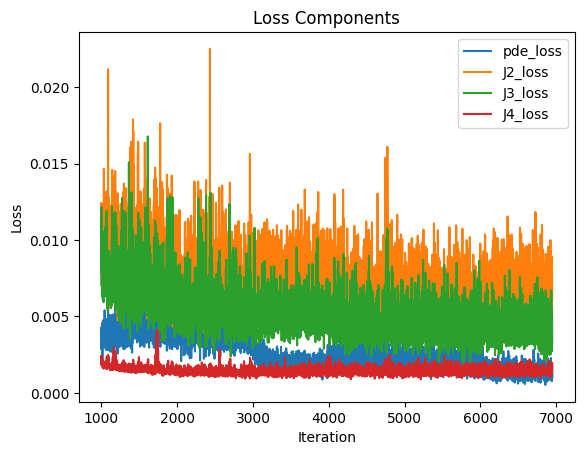

In [3]:
model.plot_losses(detailed=True, start_epoch=1000)